In [1]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import psutil
from pathlib import Path
import os

# CaImAn funtions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect, high_pass_filter_space
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

import sys
import os

sys.path.append(os.path.abspath("code"))
from utils_data import download_data
import auxiliary_functions as aux

import seaborn as sns

sns.set_theme(context='notebook', style='white', font_scale=1.5)


In [2]:
import gc
import sys

# ── Check size of large variables currently in memory ─────────────────────────
for name, obj in list(globals().items()):
    size_mb = sys.getsizeof(obj) / 1e6
    if size_mb > 50:   # only show variables larger than 50 MB
        print(f'{name:30s}  {size_mb:.0f} MB')

# ── Delete large variables that are no longer needed ──────────────────────────
# Raw movie — only needed for exercises 1 and 2A
for var in ['movie', 'original_movie', 'm_rig', 'm_els',
            'filtered_frames', 'results_pnr', 'results_corr']:
    if var in globals():
        del globals()[var]
        print(f'Deleted: {var}')

# Force garbage collection
gc.collect()
print('Garbage collection done.')

# ── Restart the cluster cleanly if it is still running ────────────────────────
try:
    cm.cluster.stop_server(dview=dview)
    print('Cluster stopped.')
except:
    print('No cluster running.')

Garbage collection done.
No cluster running.


In [3]:
# download data for the lesson (this can take a few minutes)
download_data('https://surfdrive.surf.nl/files/index.php/s/yQT6yv34jDu6csE')

In [4]:
ROI_FILE      = 'data/caiman_video_trial_0.tif'



In [5]:
# Load the ROI video
movie = cm.load(ROI_FILE)

n_frames, height, width = movie.shape
print(f'Video shape: {n_frames} frames × {height} px × {width} px')
print(f'Pixel value range: [{movie.min():.1f}, {movie.max():.1f}]')



Video shape: 500 frames × 300 px × 400 px
Pixel value range: [326.0, 1220.0]


## Exercise 1: Image characteristics
---

**A.** Distiguishing pixels

Fluctuations in the activitation of the neuron can be directly observed on the video or in a temporal trace plot of each pixel. Plotting the temporal trace will allow us to see the calcium transient dinamic, if a pixel belonging to a neuron is selected.

* Select a set of *N* random pixels from the ROI and plot the temporal evolution of pixel value. If the random pixels are choosen from an active neuron, you will be able to see the calcium transcient dynamic. Try this a few time to appreciate the results.

**B.** Temporal statistics of pixel activation
 * For the selected pixels, plot the histogram of pixel value. What are the difference in different regions?, and how can that help to distinguish a pixel that belongs to aneuron from a background pixel?

* If we can already see the calcium traces from individual pixels, why do we need to run source extraction to segment the neurons? Why, as a starter, would not be a good idea to work directly with the temporal traces of the pixels?

# **Exercise 1 A**- Distinguishing pixels


In [6]:
# Parameters
N = 6
np.random.seed(42)

# Sample N random (row, col) pixel coordinates within the ROI
rows = np.random.randint(0, height, N)
cols = np.random.randint(0, width,  N)

# Extract temporal traces

traces = [movie[:, r, c] for r, c in zip(rows, cols)]
time_axis = np.arange(n_frames) / 10.0   # convert frames → seconds (sampling rate = 10 Hz)
colors    = plt.cm.tab10(np.linspace(0, 0.9, N))

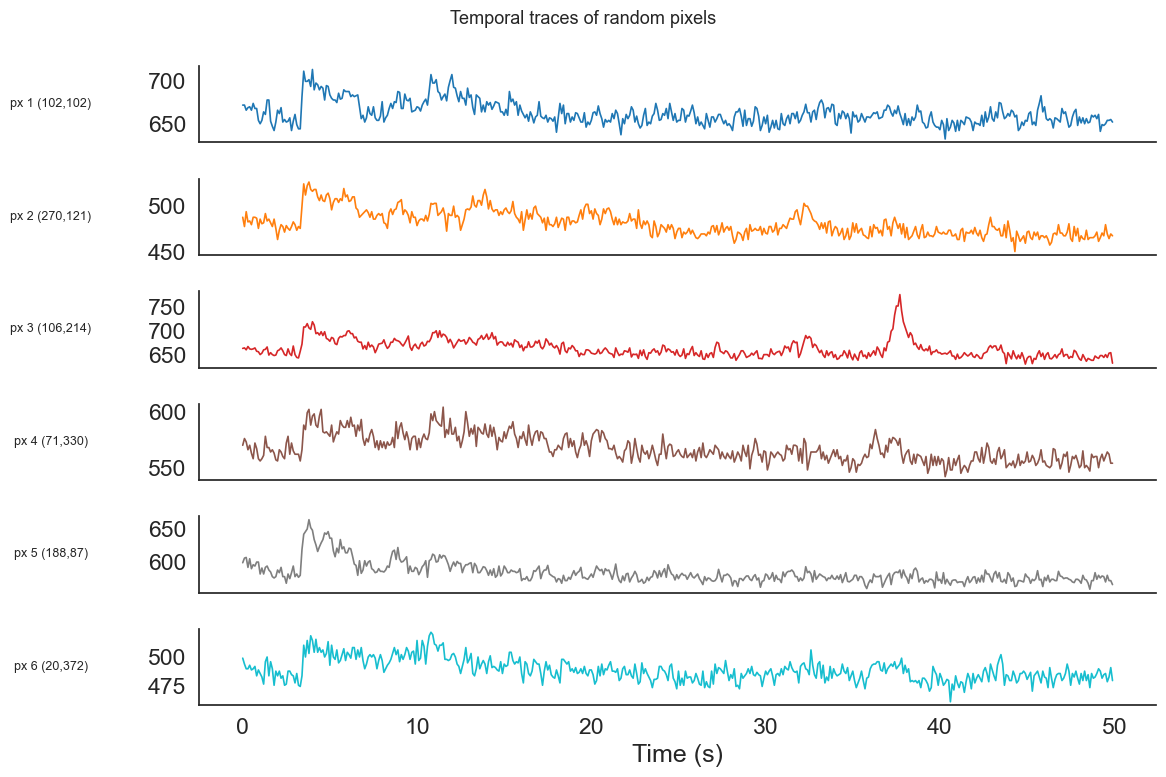

In [7]:


# Plotting the temporal traces of the selected neurons
fig2, axes = plt.subplots(N, 1, figsize=(12, 8), sharex=True)

for i, (r, c, trace) in enumerate(zip(rows, cols, traces)):
    axes[i].plot(time_axis, trace, color=colors[i], lw=1.2)
    axes[i].set_ylabel(f'px {i+1} ({r},{c})', fontsize=9,
                       rotation=0, labelpad=70, va='center')
    sns.despine(ax=axes[i])

axes[-1].set_xlabel('Time (s)')
fig2.suptitle('Temporal traces of random pixels', fontsize=13)
plt.tight_layout()
plt.show()


### **Observations**:

The temporal traces of the selected pixels show the brightness throughout time. Temporal traces with sharp peaks followed by an exponential decay (e.g: pixel 3) will most likely be a neuron. Alternatively, pixels with flat and noisy traces are thought to be background signal.


# Exercise 1B- Temporal statistics of pixel activation


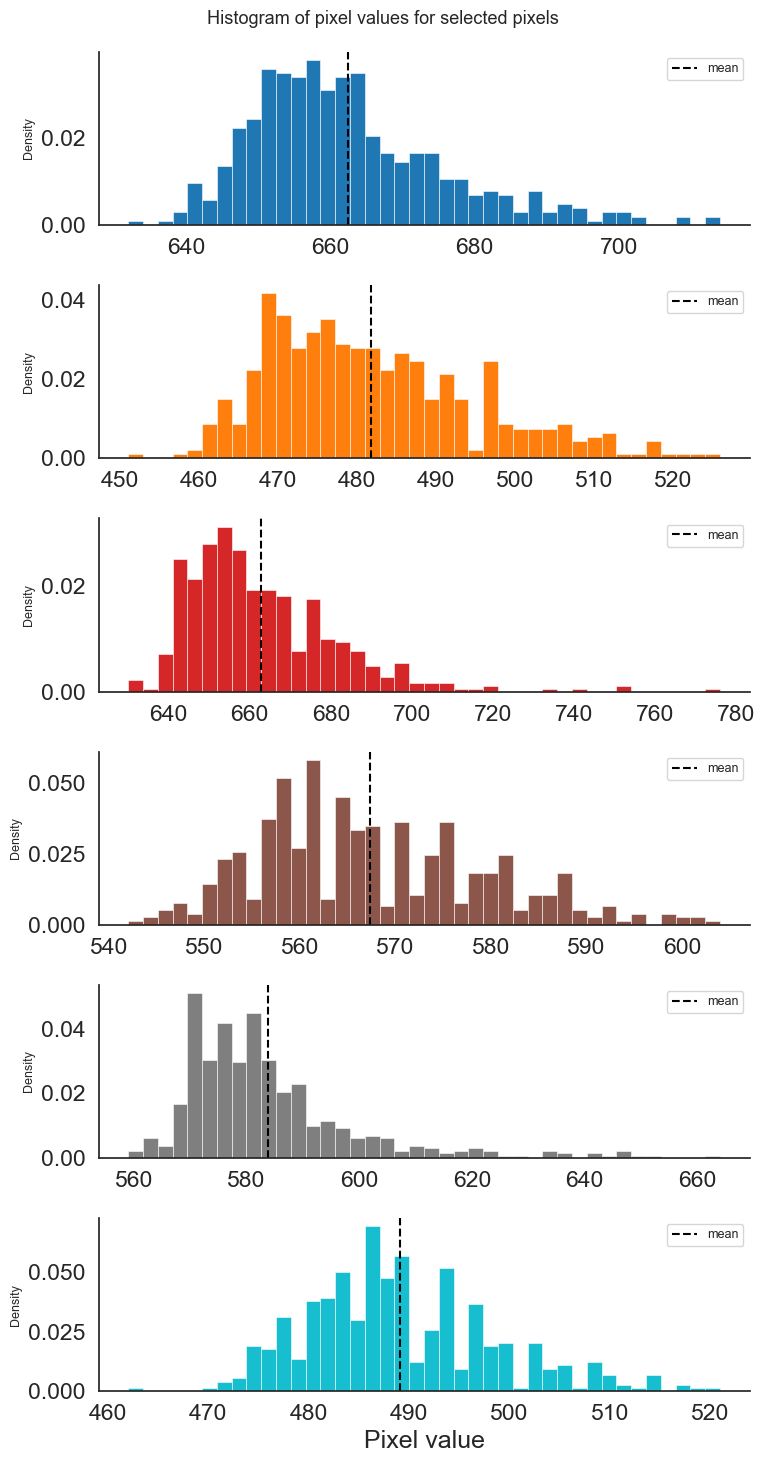

In [8]:

#Histograms for each sampled pixel
fig, axes = plt.subplots(N, 1, figsize=(8, 2.5 * N), sharex=False)

for i, (r, c, trace) in enumerate(zip(rows, cols, traces)):
    axes[i].hist(trace, bins=40, color=colors[i],
                 edgecolor='white', linewidth=0.4, density=True)
    axes[i].axvline(np.mean(trace), color='black', ls='--', lw=1.5, label='mean')
    axes[i].set_ylabel('Density', fontsize=9)

    axes[i].legend(fontsize=9)
    sns.despine(ax=axes[i])

axes[-1].set_xlabel('Pixel value')
fig.suptitle('Histogram of pixel values for selected pixels', fontsize=13)
plt.tight_layout()
plt.show()


### **Observations**:

The histograms shows the brightness of each pixel throughout the time. The x-axis shows the fluorescence intensity of the pixel, while the y- axis show the density (proportion) of that particular brightness.
 For a neuron pixel, the fluorescence occasionally spikes to high values(calcium event). This produces a skewed distribution with a tail (signal decay).
 For a background pixel, the fluorescence is constant over time, fluctuating only to noise. This produces a symmetric distribution (gaussian like).

In the example above, we can see that pixel 1,3 and 5 have a skewed distribution with a peak of density in high fluorescence values (most likely to be neuron pixels), while pixel 2,4 and 6 have a symmetric, rather flat, distribution (most likely to be background pixels)


#### *If we can already see the calcium traces from individual pixels, why do we need to run source extraction to segment the neurons? Why, as a starter, would not be a good idea to work directly with the temporal traces of the pixels?*

Firstly, 1-photon imaging does not have a high confocal resolution, which makes the signal a mix of fluorescence from multiple sources overlap in the same pixel. Thus, we cannot attribute the readout of a neuron to a single pixel. Source extraction with CNMF-E solves this problem modeling the background component.
Moreover, a neuron spans many pixels, making difficult to attribute single pixels with a biological identity. Source extraction assigns each pixel a weight for a neuron, giving a spatial footprint per cell.
Another reason is the low SNR. A single pixel has a weak signal. With source extraction we can average all the pixels belonging to a neuron footprint together, improving the SNR.



## Exercise 2: motion correction parameters
---

One parameter that impacts motion correction performance is the size of the spatial filter that is applyed to the video.

* Use the following function from CaImAn and plot the result of different space filtering applyed to a single frame of the video:from caiman.motion_correction import high_pass_filter_space

* How will this filtering affect the measure of crispness?

* Acording to Pnevmatikakis et al, which other factors are relevant for pw-rigid motion correction?

- Explore the impact of different parameters in the output of motion correction algorithm by measuring crispness in the correlation image of the final outcome. Particularly measure the effect of different spatial filter size by applying motion correction algorithm multiple times and computing the crispness of the output video.

- Display all crispness values for rigid and not rigid motion correction and plot them agains gSig_filters values.

- If possible, show the impact of the crispness value that comes from changing other relevant paraments.

*Note1: The is no need to save all the motion corrected movies, just save the cripsness values.*

*Note2: gSig_filters is an optional range of posible values, but if your computer gets to slow in the computation reduce the range.*



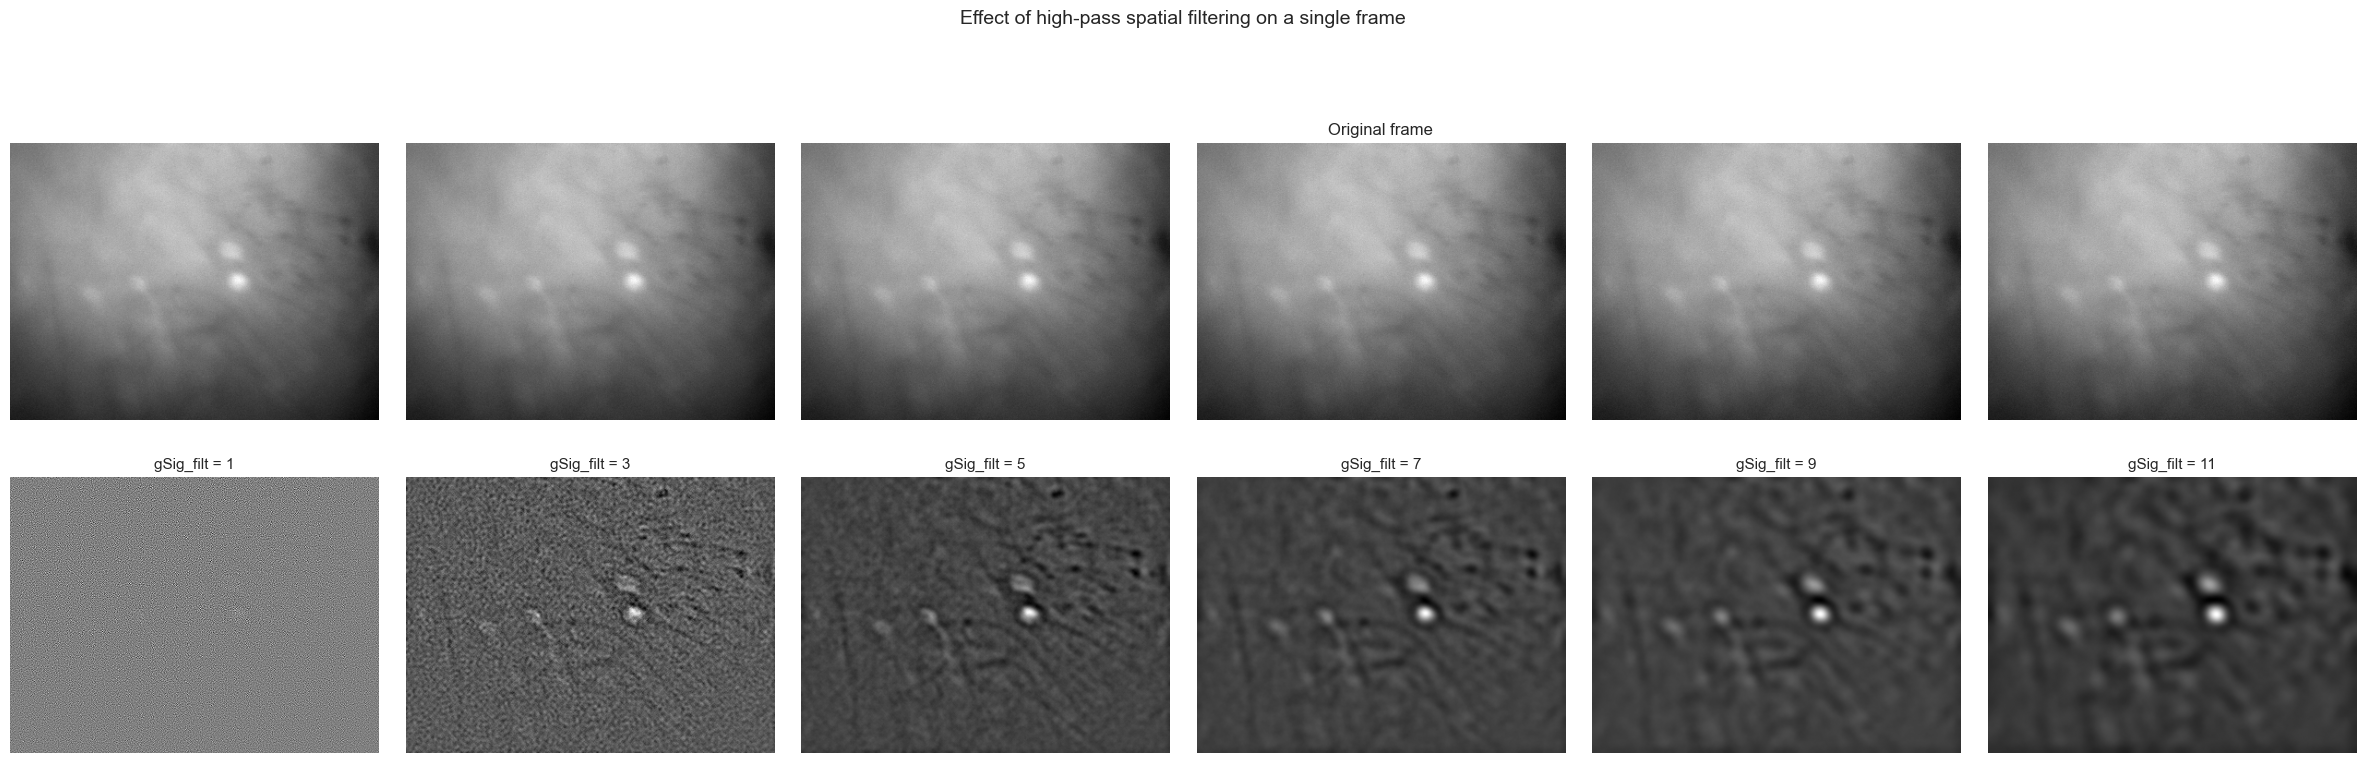

In [9]:
# Load frame
movie = cm.load(ROI_FILE)
frame = np.array(movie[100])

# Define the range of filter sizes to test
gSig_values = [1, 3, 5, 7, 9, 11]

filtered_frames = []
for g in gSig_values:
    filtered = high_pass_filter_space(frame, (g, g))
    filtered_frames.append(filtered)

#plot
n_cols = len(gSig_values)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))


for j in range(n_cols):
    axes[0, j].imshow(frame, cmap='gray')
    axes[0, j].axis('off')
    if j == n_cols // 2:
        axes[0, j].set_title('Original frame', fontsize=12)

for j, (g, ff) in enumerate(zip(gSig_values, filtered_frames)):
    axes[1, j].imshow(ff, cmap='gray')
    axes[1, j].set_title(f'gSig_filt = {g}', fontsize=11)
    axes[1, j].axis('off')

plt.suptitle('Effect of high-pass spatial filtering on a single frame',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Effect of filter size on single frames

High pass filter size determines the size of the Gaussian kernel SD. Thus, large filters blur over wide areas, removing background but also erasing other components of the images (e.g 9,11). Small filters blurry only immediate neighbouring areas, subtracting little background (e.g 1)
Importantly, we cannot determine the optimal filter with this qualitative view. We are visualizing a single frame with different size filters, not the motion corrected output.
To determine which is the optimal size, we should perform a motion corrrection and check for quantitative measurements as crispness.

In [10]:
n_processes = psutil.cpu_count()  # counts local cpus
cm.cluster.stop_server()  #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

In [11]:
# gSig_filt values to test
gSig_test_values = [3, 5, 7, 9, 11]

base_mc_dict = {
    'pw_rigid': True,
    'max_shifts': (25, 25),
    'niter_rig': 1,
    'strides': (48, 48),
    'overlaps': (96, 96),
    'upsample_factor_grid': 1,
    'num_frames_split': 80,
    'max_deviation_rigid': 15,
    'shifts_opencv': True,
    'use_cuda': False,
    'nonneg_movie': True,
    'border_nan': 'copy',
}

original_movie = cm.load(ROI_FILE)
base_mc_dict['min_mov'] = np.min(original_movie)
del original_movie

# crispness parameters
winsize = 100
swap_dim = False
resize_fact_flow = 0.1

crispness_rigid = []
crispness_pwrigid = []

for g in gSig_test_values:
    print(f'\n── gSig_filt = {g} ─')

    parameters_motion_correction = base_mc_dict.copy()
    parameters_motion_correction['gSig_filt'] = (g, g)

    opts = params.CNMFParams(params_dict=parameters_motion_correction)
    mc = MotionCorrect(ROI_FILE, dview=dview, **opts.get_group('motion'))
    mc.motion_correct_rigid(save_movie=True, template=None)
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

    final_size = mc.total_template_els.shape

    #Crispness
    _, _, _, _, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False,
        resize_fact_flow=resize_fact_flow)

    _, _, _, _, crisp_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False,
        resize_fact_flow=resize_fact_flow)

    crispness_rigid.append(int(crisp_rig))
    crispness_pwrigid.append(int(crisp_els))

    print(f'  Rigid crispness   : {int(crisp_rig)}')
    print(f'  PW-rigid crispness: {int(crisp_els)}')

    # NOTE: I need to delete the frame in order to release memory.
    import gc

    gc.collect()
    for f in mc.fname_tot_rig + mc.fname_tot_els:
        try:
            Path(f).unlink()
            print(f'  Deleted: {Path(f).name}')
        except Exception as e:
            print(f'  Could not delete {Path(f).name}: {e}')


print('Rigid:   ', crispness_rigid)
print('PW-rigid:', crispness_pwrigid)


── gSig_filt = 3 ─


In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 1046
  PW-rigid crispness: 1044
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── gSig_filt = 5 ─


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 858
  PW-rigid crispness: 882
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── gSig_filt = 7 ─


...

  Rigid crispness   : 826
  PW-rigid crispness: 866
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── gSig_filt = 9 ─


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 820
  PW-rigid crispness: 873
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── gSig_filt = 11 ─


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.


  Rigid crispness   : 825
  PW-rigid crispness: 882
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap
Rigid:    [1046, 858, 826, 820, 825]
PW-rigid: [1044, 882, 866, 873, 882]



### Effect of filter size on crispness values:

The maximum value of crispness is the one with filter=3 in both rigid and PW motion correction. This gives us a quantitative measure of the effect of the spatial filter on how sharp is the correlation image. With filters higher than 3 the crispness decreases, which means the gradient is blurrier.

Filter size has an impact on crispness because it determines the alignment of the frames to create a sharper image (sharpness is what crispness measures)

Another observation is that PW-rigid crispness is often higher than the rigid crispness. This is a coherent observation due to PW-rigid specifically applies different shifts to different patches within the frame, while rigid correction applies only one shift per frame.

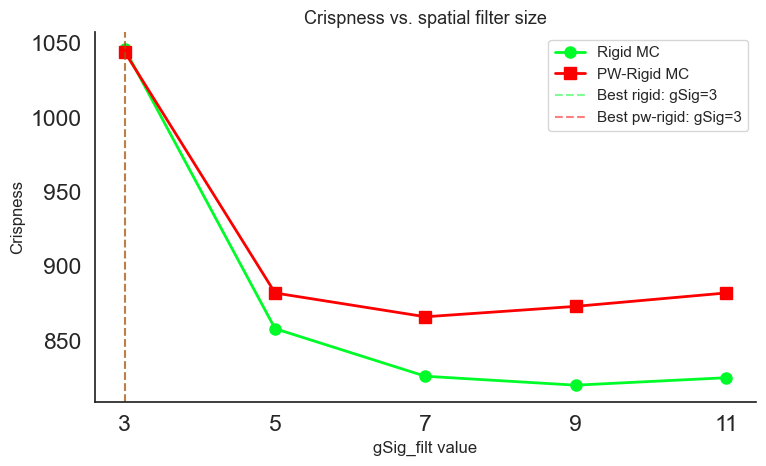

In [12]:
#Plot crispness vs gSig_filt
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(gSig_test_values, crispness_rigid, 'o-', color='#00FC28',
        linewidth=2, markersize=8, label='Rigid MC')
ax.plot(gSig_test_values, crispness_pwrigid, 's-', color='#FC0000',
        linewidth=2, markersize=8, label='PW-Rigid MC')


best_rig = gSig_test_values[np.argmax(crispness_rigid)]
best_pwr = gSig_test_values[np.argmax(crispness_pwrigid)]

ax.axvline(best_rig, color='#00FC28', ls='--', alpha=0.5, label=f'Best rigid: gSig={best_rig}')
ax.axvline(best_pwr, color='#FC0000', ls='--', alpha=0.5, label=f'Best pw-rigid: gSig={best_pwr}')

ax.set_xlabel('gSig_filt value', fontsize=12)
ax.set_ylabel('Crispness', fontsize=12)
ax.set_title('Crispness vs. spatial filter size',
             fontsize=13)
ax.set_xticks(gSig_test_values)
ax.legend(fontsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The best filter value is 3 in both rigid and PW-rigid. 5,7,9 and 11 filter values result in a higher crispness in Pw-rigid than in rigid MC.

### Other relevant factors:
1. Maximum shifts (*max_shifts*):In a very noisy frame, the algorithm can find high cross correlations of two pixels far away from each other.  To avoid this, we apply a maximum shift order in which no frame can be translated more than this value in any direction (maximum allowed displacement)
2. Merging overlapping patches: When applying non-rigid motion correction (PW-rigid) each path is analyzed independently and this can cause seams at patch boundaries. Merging this patches will create a smooth transition between patches.
3. Avoiding smearing by upsampling (*usample_factor_grid*): This creates a finer grid (with more subpatches) to make a smooth gradient transition between patches.
4. Choosing patch size and amount of overlap (*strides and overlaps*): The size of the patches (strides) has to be large enough to contain signal for reliable cross-relation, and small enough to capture local non-rigid transformations. For the overlap is recommended to be the diameter of a neuron in pixels to avoid spliting neurons between two patches.

 We will now explore the effect of varying the *max_shift* and *stride* value on crispness.


In [13]:
#Max shifts values to test
max_shifts_values = [1, 5, 10]

base_mc_dict = {
    'pw_rigid': True,
    'max_shifts': (25, 25),
    'niter_rig': 1,
    'strides': (48, 48),
    'overlaps': (96, 96),
    'upsample_factor_grid': 1,
    'num_frames_split': 80,
    'max_deviation_rigid': 15,
    'shifts_opencv': True,
    'use_cuda': False,
    'nonneg_movie': True,
    'border_nan': 'copy',
    'gSig_filt': (5, 5),
}

original_movie = cm.load(ROI_FILE)
base_mc_dict['min_mov'] = np.min(original_movie)
del original_movie

# crispness parameters
winsize = 100
swap_dim = False
resize_fact_flow = 0.1

crispness_rigid = []
crispness_pwrigid = []

for ms in max_shifts_values:
    print(f'\n── max_shifts = {ms} ─────')

    parameters_motion_correction = base_mc_dict.copy()
    parameters_motion_correction['max_shifts'] = (ms, ms)

    opts = params.CNMFParams(params_dict=parameters_motion_correction)
    mc = MotionCorrect(ROI_FILE, dview=dview, **opts.get_group('motion'))
    mc.motion_correct_rigid(save_movie=True, template=None)
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

    final_size = mc.total_template_els.shape

    # Crispness on mean image
    _, _, _, _, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False,
        resize_fact_flow=resize_fact_flow)

    _, _, _, _, crisp_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False,
        resize_fact_flow=resize_fact_flow)

    crispness_rigid.append(int(crisp_rig))
    crispness_pwrigid.append(int(crisp_els))

    print(f'  Rigid crispness   : {int(crisp_rig)}')
    print(f'  PW-rigid crispness: {int(crisp_els)}')

    import gc

    gc.collect()
    for f in mc.fname_tot_rig + mc.fname_tot_els:
        try:
            Path(f).unlink()
            print(f'  Deleted: {Path(f).name}')
        except Exception as e:
            print(f'  Could not delete {Path(f).name}: {e}')


print('Rigid:   ', crispness_rigid)
print('PW-rigid:', crispness_pwrigid)

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)



── max_shifts = 1 ─────


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 870
  PW-rigid crispness: 883
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── max_shifts = 5 ─────


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 859
  PW-rigid crispness: 882
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── max_shifts = 10 ─────


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.


  Rigid crispness   : 858
  PW-rigid crispness: 882
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap
Rigid:    [870, 859, 858]
PW-rigid: [883, 882, 882]



### Effect of max_shifts on crispness:

As we can see the values for crispness barely change. This suggests that the motion of the video is small and max_shift is not a sensitive parameter for this data.

In [14]:
#Strides values to test (overlaps fixed)
strides_values = [24, 48, 64]

base_mc_dict = {
    'pw_rigid': True,
    'max_shifts': (25, 25),
    'niter_rig': 1,
    'strides': (48, 48),
    'overlaps': (96, 96),
    'upsample_factor_grid': 1,
    'num_frames_split': 80,
    'max_deviation_rigid': 15,
    'shifts_opencv': True,
    'use_cuda': False,
    'nonneg_movie': True,
    'border_nan': 'copy',
    'gSig_filt': (5, 5),
}

original_movie = cm.load(ROI_FILE)
base_mc_dict['min_mov'] = np.min(original_movie)
del original_movie

winsize = 100
swap_dim = False
resize_fact_flow = 0.1

crispness_rigid = []
crispness_pwrigid = []

for st in strides_values:
    print(f'\n── strides = {st} ─────')

    parameters_motion_correction = base_mc_dict.copy()
    parameters_motion_correction['strides'] = (st, st)

    opts = params.CNMFParams(params_dict=parameters_motion_correction)
    mc = MotionCorrect(ROI_FILE, dview=dview, **opts.get_group('motion'))
    mc.motion_correct_rigid(save_movie=True, template=None)
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

    final_size = mc.total_template_els.shape

    _, _, _, _, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False,
        resize_fact_flow=resize_fact_flow)

    _, _, _, _, crisp_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0], final_size[0], final_size[1],
        swap_dim, winsize=winsize, play_flow=False,
        resize_fact_flow=resize_fact_flow)

    crispness_rigid.append(int(crisp_rig))
    crispness_pwrigid.append(int(crisp_els))

    print(f'  Rigid crispness   : {int(crisp_rig)}')
    print(f'  PW-rigid crispness: {int(crisp_els)}')

    import gc

    gc.collect()
    for f in mc.fname_tot_rig + mc.fname_tot_els:
        try:
            Path(f).unlink()
            print(f'  Deleted: {Path(f).name}')
        except Exception as e:
            print(f'  Could not delete {Path(f).name}: {e}')

print('\nDone.')
print('Rigid:   ', crispness_rigid)
print('PW-rigid:', crispness_pwrigid)

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)



── strides = 24 ─────


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 858
  PW-rigid crispness: 893
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── strides = 48 ─────


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


  Rigid crispness   : 858
  PW-rigid crispness: 882
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

── strides = 64 ─────


Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.


  Rigid crispness   : 858
  PW-rigid crispness: 876
  Deleted: caiman_video_trial_0_rig__d1_300_d2_400_d3_1_order_F_frames_500.mmap
  Deleted: caiman_video_trial_0_els__d1_300_d2_400_d3_1_order_F_frames_500.mmap

Done.
Rigid:    [858, 858, 858]
PW-rigid: [893, 882, 876]



### Effect of stride values on crispness:

As we can see the crispness decreases in PW-rigid with increasing stride values. This observation is coherent with the paper by Pnevmatikakis et al, which claims that patch size is relevant for non-rigid motion correction. Larger patches estimate the shift for a wide region, probably missing local shifts.

## Exercise 3: Source extraction parameters
---

* For a fixed minimum correlation value (ie 0.6) select a range of possible PNR minimun values and study the impact of those in the final source extraction output.

* For a fixed value of PNR (ie 6) select a range of minimum correlation valur and study the impact of those in the final source extraction output.

* How do these paramenters affect the spatial sparcity of the output? Which set of parameter selection procedes the higher number of neurons? Is maximal number of neurons always better? Why?

* Generate a plot of number of neurons vs PNR (or min corr value) to show how these parameters affect the source extracted signals.

* Are the temporal traces affected by these parameters?

* For different PNR and minimum correlation value plot the correlation image and the selected cells.

In [15]:
# Motion correction parameters from the lesson

parameters_motion_correction = {'pw_rigid': True,
                                # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),  # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),
                                # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1,
                                'strides': (48, 48),  # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),  # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,
                                # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15,
                                # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True,
                                'use_cuda': False,
                                'nonneg_movie': True,
                                'border_nan': 'copy'}

# We compute and store the minimum value of the movie, that the algorithm needs to make values all positive
original_movie = cm.load(ROI_FILE)
parameters_motion_correction['min_mov'] = np.min(original_movie)
del original_movie

opts = params.CNMFParams(params_dict=parameters_motion_correction)
mc = MotionCorrect(ROI_FILE, dview=dview, **opts.get_group('motion'))
mc.motion_correct_rigid(save_movie=True, template=None)
mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

#Save in C order
m_els = cm.load(mc.fname_tot_els)
MMAP_FILE = m_els.save('motion_corrected_video.mmap', order='C')
del m_els

print(f'C order mmap saved to:\n  {MMAP_FILE}')

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


C order mmap saved to:
  C:\Users\4bmar\caiman_data\temp\motion_corrected_video_d1_300_d2_400_d3_1_order_C_frames_500.mmap


In [16]:
#Load for exercise 3
Yr, dims, T = cm.load_memmap(MMAP_FILE)
images = np.reshape(Yr.T, [T] + list(dims), order='C')

print(f'Loaded: {T} frames x {dims[0]} x {dims[1]} px')
# Compute correlation and PNR images
gSig = 9
corr_img, pnr_img = cm.summary_images.correlation_pnr(images[::1], gSig=gSig,
                                                        swap_dim=False)

Loaded: 500 frames x 300 x 400 px


In [17]:
#Source extraction  parameters from the lesson
parameters_source_extraction ={ 'fr': 10,               # movie frame rate
                               'decay_time': 0.1,       # length of a typical transient in seconds
                               'min_corr': 0.7,   # min peak value from correlation image
                               'min_pnr': 7,     # min peak to noise ration from PNR image
                                'p': 1,                # order of the autoregressive system
                               'K': None,              # upper bound on number of components per patch, in general None
                               'gSig': (4, 4),         # gaussian width of a 2D gaussian kernel, which approximates a neuron
                               'gSiz': (17, 17),       # average diameter of a neuron, in general 4*gSig+1
                               'ring_size_factor': 1.4, # radius of ring is gSiz*ring_size_factor
                               'merge_thr': 0.7, 'rf': 60,
                               'stride': 30, 'tsub': 1, 'ssub': 2, 'p_tsub': 1, 'p_ssub': 2, 'low_rank_background': None,
                               'nb': 0, 'nb_patch': 0, 'ssub_B': 2, 'init_iter': 2,
                               'method_init': 'corr_pnr', 'method_deconvolution': 'oasis',
                               'update_background_components': True,
                               'center_psf': True, 'border_pix': 0, 'normalize_init': False,
                               'del_duplicates': True, 'only_init': True}

### Min_pnr:
PNR values with fixed min_corr values

In [18]:
# Create output directory
Path("data/source_extracted").mkdir(parents=True, exist_ok=True)

fixed_corr = 0.6
pnr_values = [3, 6, 8, 10]

# Store results as explicit matrices
n_neurons_pnr = []
A_pnr = []
C_pnr = []

for pnr in pnr_values:
    print(f'Running CNMF-E: min_corr={fixed_corr}, min_pnr={pnr} ...', end=' ', flush=True)

    opts = params.CNMFParams(params_dict={**parameters_source_extraction,
                                          'min_corr': fixed_corr,
                                          'min_pnr': pnr})
    cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
    cnmf_object.fit(images)

    # Save as hdf5
    output_cnmf_file_path = f'data/source_extracted/cnmf_mincorr{fixed_corr}_minpnr{pnr}.hdf5'
    cnmf_object.save(output_cnmf_file_path)
    print(f'→ saved to {output_cnmf_file_path}')

    # Extract and store matrices
    A = cnmf_object.estimates.A
    C = cnmf_object.estimates.C
    n = A.shape[1]

    n_neurons_pnr.append(n)
    A_pnr.append(A)
    C_pnr.append(C)

    print(f'→ {n} neurons found')

print('\nDone.')
print('Neurons per pnr value:', n_neurons_pnr)

Running CNMF-E: min_corr=0.6, min_pnr=3 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.6_minpnr3.hdf5
→ 97 neurons found
Running CNMF-E: min_corr=0.6, min_pnr=6 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.6_minpnr6.hdf5
→ 42 neurons found
Running CNMF-E: min_corr=0.6, min_pnr=8 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.6_minpnr8.hdf5
→ 15 neurons found
Running CNMF-E: min_corr=0.6, min_pnr=10 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.6_minpnr10.hdf5
→ 9 neurons found

Done.
Neurons per pnr value: [97, 42, 15, 9]


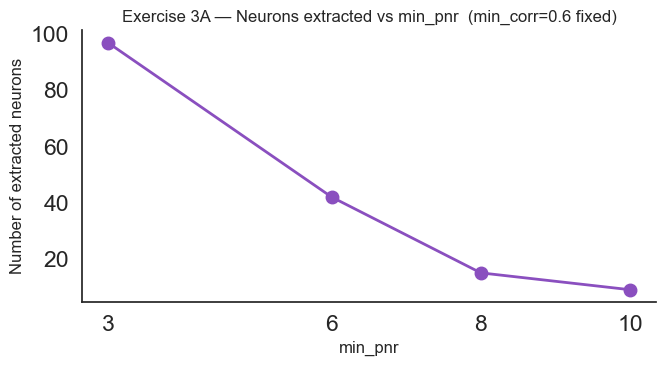

In [19]:
#Plot: number of neurons vs min_pnr
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pnr_values, n_neurons_pnr, 'o-', color='#8a4fbf', linewidth=2, markersize=9)
ax.set_xlabel('min_pnr', fontsize=12)
ax.set_ylabel('Number of extracted neurons', fontsize=12)
ax.set_title(f'Exercise 3A — Neurons extracted vs min_pnr  (min_corr={fixed_corr} fixed)',
             fontsize=12)
ax.set_xticks(pnr_values)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


#### Impact on source extraction output and spatial sparcity:
In this case the effects both on output and spatial sparcity relates to the value of thresholds. Higher thresholds set a high signal strength value to be considered as a source. This causes the extraction of most clearly defined neurons, being stricter and reulsting in a less number of neurons.

Contrarily, low threshold values are more permissive and allow to extract more neurons

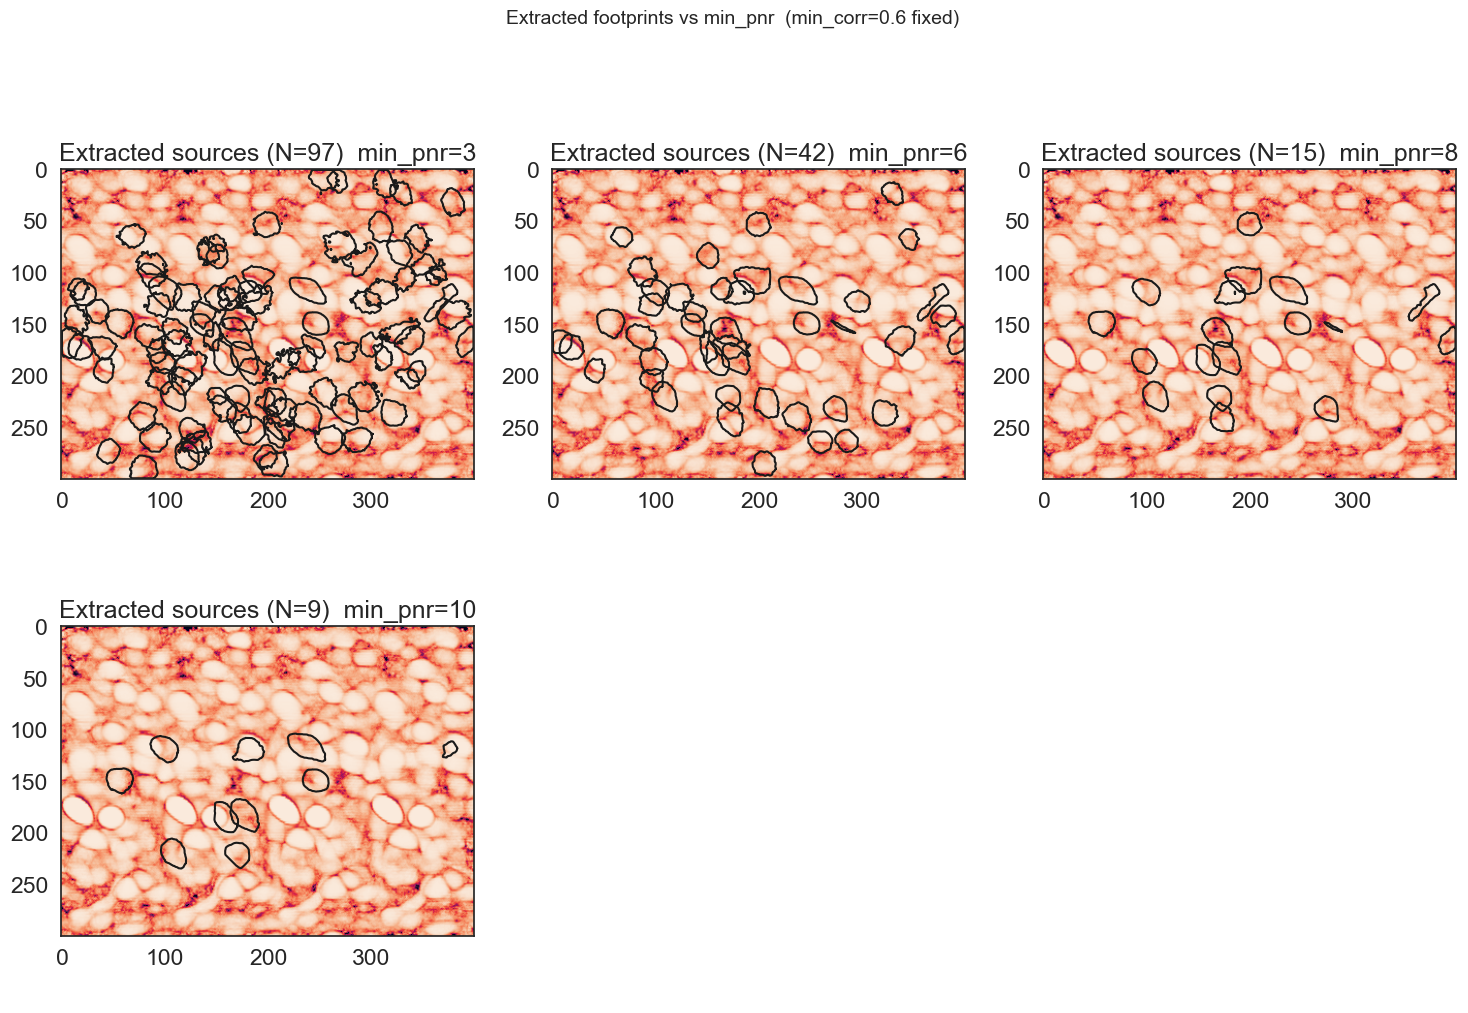

In [20]:
n_plots = len(pnr_values)
n_cols = min(3, n_plots)
n_rows = int(np.ceil(n_plots / n_cols))

figure, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows),
                            squeeze=False)
axes = axes.flatten()

for i, (pnr, n_neurons, A) in enumerate(zip(pnr_values, n_neurons_pnr, A_pnr)):
    axes[i].imshow(corr_img)
    axes[i].set_title(f'Extracted sources (N={n_neurons})  min_pnr={pnr}')
    coordinates = cm.utils.visualization.get_contours(A, np.shape(corr_img), 0.2, 'max')
    for c in coordinates:
        v = c['coordinates']
        c['bbox'] = [np.floor(np.nanmin(v[:, 1])), np.ceil(np.nanmax(v[:, 1])),
                     np.floor(np.nanmin(v[:, 0])), np.ceil(np.nanmax(v[:, 0]))]
        axes[i].plot(*v.T, c='k')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Extracted footprints vs min_pnr  (min_corr={fixed_corr} fixed)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### Is a higher number of neurons always better?

We can answer this question by looking at the footprints plotted over the correlation images. Low min_pnr values make footprints overlap between each other, considering artifacts as footprints (e.g min_pnr=3). Alternatively, high min_pnr values extract very little amount of neurons, missing true neurons(e.g min_pnr=10)


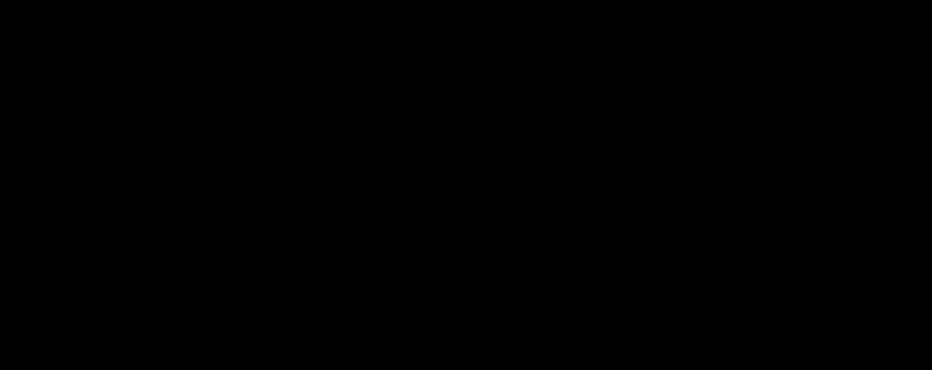
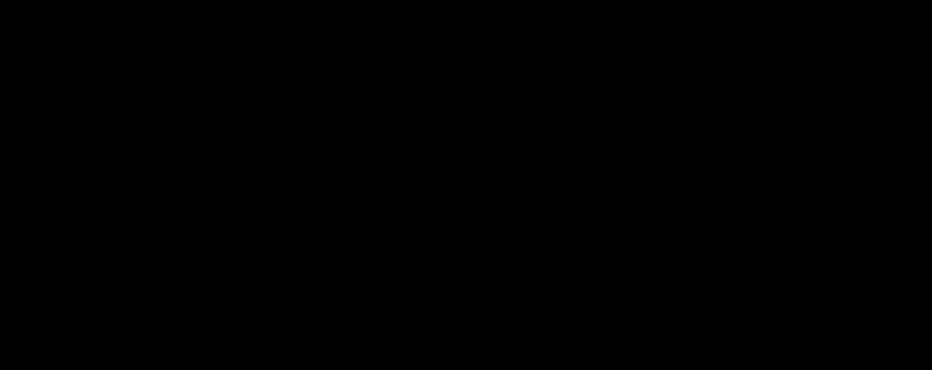
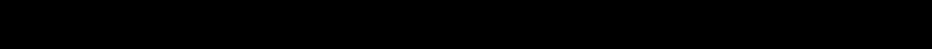


### Min_corr:

min_corr values with fixed min_pnr value

In [21]:
fixed_pnr = 6
corr_values = [0.3, 0.6, 0.7, 0.8]

n_neurons_corr = []
A_corr = []
C_corr = []

for corr in corr_values:
    print(f'Running CNMF-E: min_corr={corr}, min_pnr={fixed_pnr} ...', end=' ', flush=True)

    opts = params.CNMFParams(params_dict={**parameters_source_extraction,
                                          'min_corr': corr,
                                          'min_pnr': fixed_pnr})
    cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
    cnmf_object.fit(images)

    # ── Save as hdf5 — exactly as lesson cell 39 ──────────────────────────────
    output_cnmf_file_path = f'data/source_extracted/cnmf_mincorr{corr}_minpnr{fixed_pnr}.hdf5'
    cnmf_object.save(output_cnmf_file_path)
    print(f'→ saved to {output_cnmf_file_path}')

    # ── Extract and store matrices ─────────────────────────────────────────────
    A = cnmf_object.estimates.A
    C = cnmf_object.estimates.C
    n = A.shape[1]

    n_neurons_corr.append(n)
    A_corr.append(A)
    C_corr.append(C)

    print(f'→ {n} neurons found')


print('Neurons per corr value:', n_neurons_corr)

Running CNMF-E: min_corr=0.3, min_pnr=6 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.3_minpnr6.hdf5
→ 47 neurons found
Running CNMF-E: min_corr=0.6, min_pnr=6 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.6_minpnr6.hdf5
→ 42 neurons found
Running CNMF-E: min_corr=0.7, min_pnr=6 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.7_minpnr6.hdf5
→ 35 neurons found
Running CNMF-E: min_corr=0.8, min_pnr=6 ... 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)


→ saved to data/source_extracted/cnmf_mincorr0.8_minpnr6.hdf5
→ 26 neurons found

Done.
Neurons per corr value: [47, 42, 35, 26]


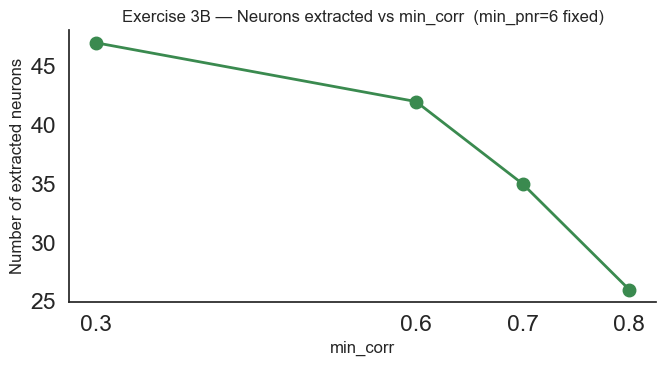

In [22]:
# ── Plot: number of neurons vs min_corr ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(corr_values, n_neurons_corr, 'o-', color='#3a8a4f', linewidth=2, markersize=9)
ax.set_xlabel('min_corr', fontsize=12)
ax.set_ylabel('Number of extracted neurons', fontsize=12)
ax.set_title(f'Exercise 3B — Neurons extracted vs min_corr  (min_pnr={fixed_pnr} fixed)',
             fontsize=12)
ax.set_xticks(corr_values)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


#### Impact on source extraction output and spatial sparcity:

The minimum correlation looks for pixels that are synchronyzed with neighbouring pixels. Setting a high value, the algorithm will only accept pixels highly correlated (strict approach). Whereas, setting a low value is a more permissive approach due to the correlation between pixels can be lower to be considered a footprint.

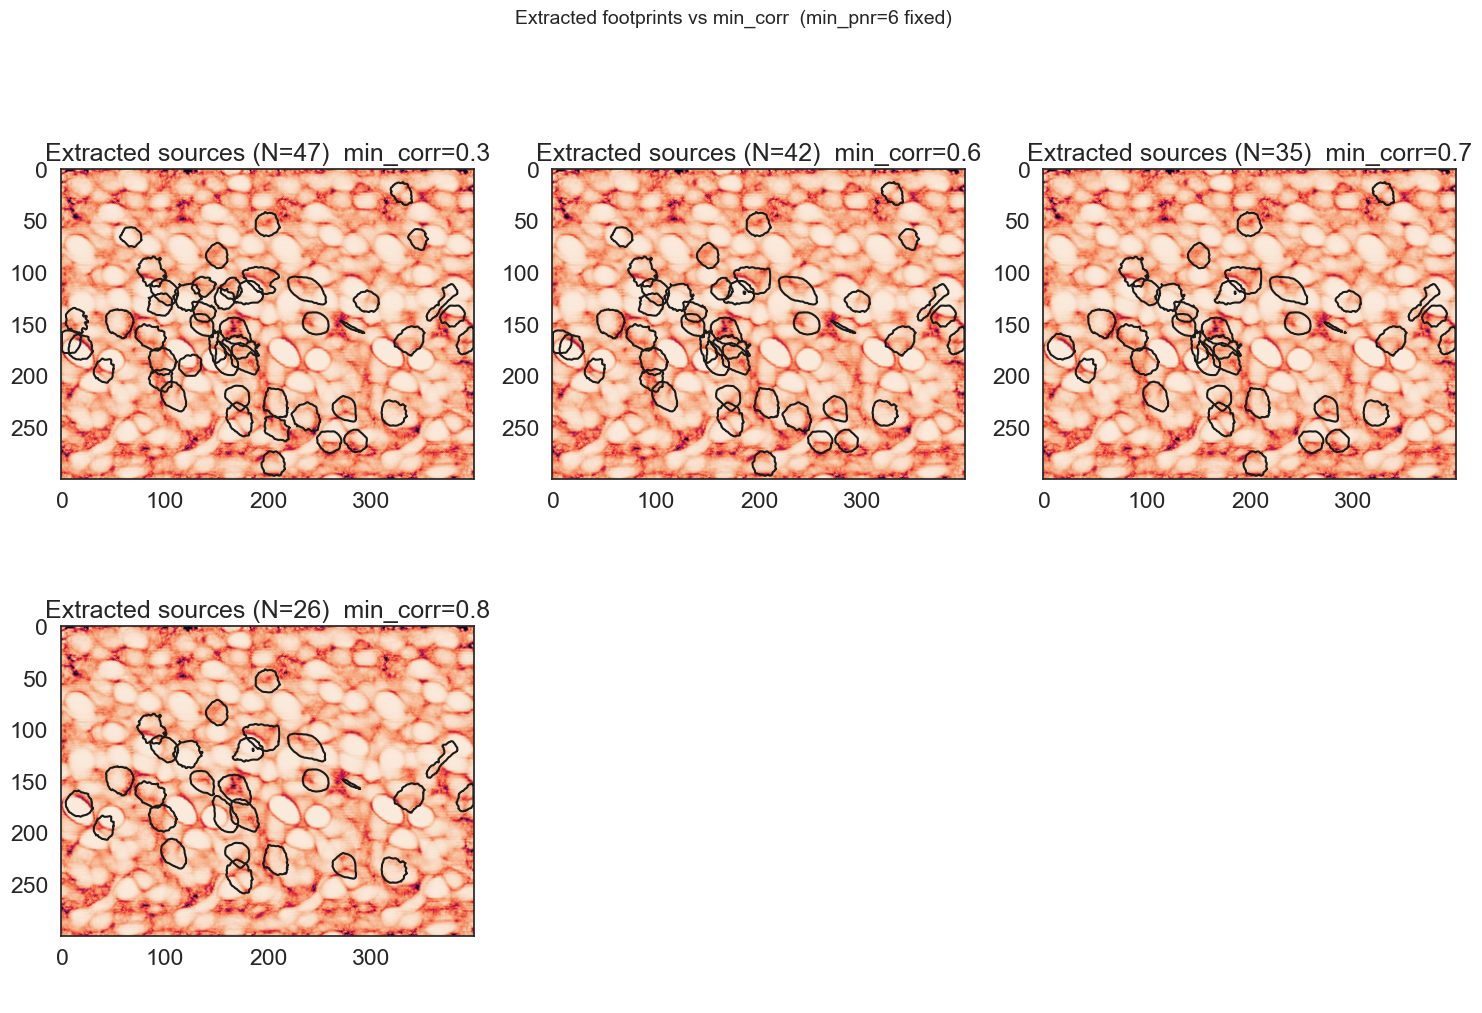

In [23]:
n_plots = len(corr_values)
n_cols = min(3, n_plots)
n_rows = int(np.ceil(n_plots / n_cols))

figure, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows),
                            squeeze=False)
axes = axes.flatten()

for i, (corr, n_neurons, A) in enumerate(zip(corr_values, n_neurons_corr, A_corr)):
    axes[i].imshow(corr_img)
    axes[i].set_title(f'Extracted sources (N={n_neurons})  min_corr={corr}')
    coordinates = cm.utils.visualization.get_contours(A, np.shape(corr_img), 0.2, 'max')
    for c in coordinates:
        v = c['coordinates']
        c['bbox'] = [np.floor(np.nanmin(v[:, 1])), np.ceil(np.nanmax(v[:, 1])),
                     np.floor(np.nanmin(v[:, 0])), np.ceil(np.nanmax(v[:, 0]))]
        axes[i].plot(*v.T, c='k')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Extracted footprints vs min_corr  (min_pnr={fixed_pnr} fixed)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### Is a higher number of neurons always better?
 As we did with min_pnr we can answer this question by looking at the footprints plotted over the correlation images at different parameter values.

We can observe the same as with min_pnr: low values cause the detection of artifacts (too permisive), while high values only detect high correlated pixels, missing out some neurons (too strict).

As a conclusion, the goal is to find a pair of parameter values (min_corr and min_pnr) that maximizes true positives and minimizes false negative.
A good approach to find these optimal values is to inspect the footprints in the correlation images as we did.

#### Are the temporal traces affected by these parameters?

A simple reasoning would indicate that temporal traces are not affected by these parameters that are relevant for the spatial matrix (A) in our model.

To test this, I selected the same neurons (matching them) and check their temporal traces in different runs with the highest and lowest value parameter (fro min_pnr and min_corr)

For matching the cells, I selected an arbitrary threshold=0.7 of spatial correlation between the cell in the first run and second run. This will, most likely, select the same cell from both runs.

In [24]:
from scipy.sparse import issparse


def match_cells(A1, A2, threshold=0.7):

    # Convert sparse matrices to dense if necessary — CaImAn stores A as sparse
    if issparse(A1): A1 = A1.toarray()
    if issparse(A2): A2 = A2.toarray()

    matched_pairs = []
    for i in range(A1.shape[1]):
        for j in range(A2.shape[1]):
            # correlation between footprint i in run1 and footprint j in run2
            corr = np.corrcoef(A1[:, i], A2[:, j])[0, 1]
            if corr > threshold:
                matched_pairs.append((i, j, corr))

    # keep only the best match for each cell in run1
    best_matches = {}
    for i, j, corr in matched_pairs:
        if i not in best_matches or corr > best_matches[i][1]:
            best_matches[i] = (j, corr)

    return [(i, j, corr) for i, (j, corr) in best_matches.items()]

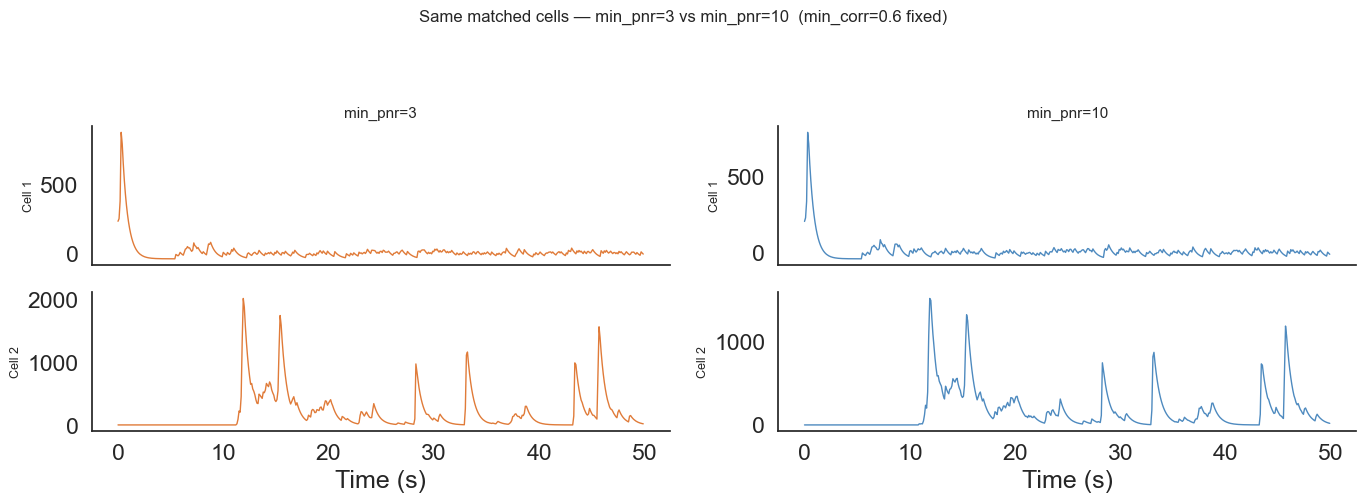

In [25]:
# Match cells between lowest and highest min_pnr


lowest_pnr_idx  = pnr_values.index(3)
highest_pnr_idx = pnr_values.index(10)

matches_pnr = match_cells(A_pnr[lowest_pnr_idx], A_pnr[highest_pnr_idx])
C1_pnr      = C_pnr[lowest_pnr_idx]
C2_pnr      = C_pnr[highest_pnr_idx]
n_show = min(2, len(matches_pnr))
time_ax = np.arange(C_pnr[0].shape[1]) / 10.0

# Convert to dense for indexing
C1_pnr = C_pnr[0]
C2_pnr = C_pnr[-1]

figure, axes = plt.subplots(n_show, 2, figsize=(14, 2.5 * n_show), sharex=True)

for row, (idx1, idx2, spatial_corr) in enumerate(matches_pnr[:n_show]):
    for col, (C, idx, pnr, color) in enumerate([
        (C1_pnr, idx1, pnr_values[0], '#e07b39'),
        (C2_pnr, idx2, pnr_values[-1], '#4e8abf'),
    ]):
        axes[row, col].plot(time_ax, C[idx], color=color, lw=1.0)
        axes[row, col].set_ylabel(f'Cell {row + 1}', fontsize=9)
        sns.despine(ax=axes[row, col])
        if row == 0:
            axes[row, col].set_title(f'min_pnr={pnr}', fontsize=11)
        if row == n_show - 1:
            axes[row, col].set_xlabel('Time (s)')

plt.suptitle(f'Same matched cells — min_pnr={pnr_values[0]} vs min_pnr={pnr_values[-1]}'
             f'  (min_corr={fixed_corr} fixed)\n'
           ,
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


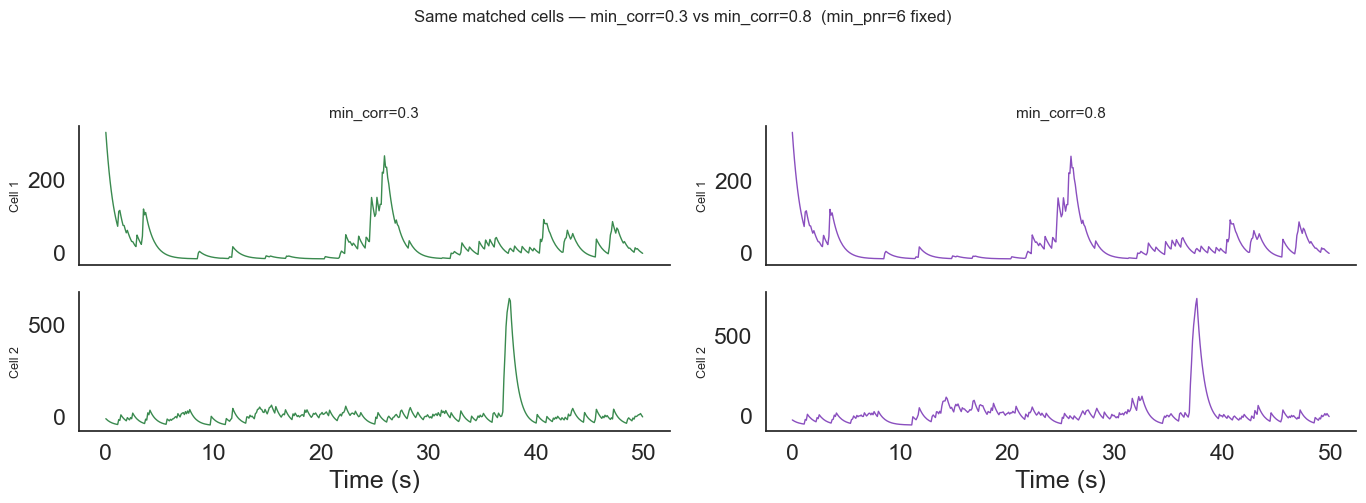

In [26]:
#  Match cells between lowest and highest min_corr
matches_corr = match_cells(A_corr[0], A_corr[-1])
n_show = min(2, len(matches_corr))
time_ax = np.arange(C_corr[0].shape[1]) / 10.0

C1_corr = C_corr[0]
C2_corr = C_corr[-1]

figure, axes = plt.subplots(n_show, 2, figsize=(14, 2.5 * n_show), sharex=True)

for row, (idx1, idx2, spatial_corr) in enumerate(matches_corr[:n_show]):
    for col, (C, idx, corr_val, color) in enumerate([
        (C1_corr, idx1, corr_values[0], '#3a8a4f'),
        (C2_corr, idx2, corr_values[-1], '#8a4fbf'),
    ]):
        axes[row, col].plot(time_ax, C[idx], color=color, lw=1.0)
        axes[row, col].set_ylabel(f'Cell {row + 1}', fontsize=9)
        sns.despine(ax=axes[row, col])
        if row == 0:
            axes[row, col].set_title(f'min_corr={corr_val}', fontsize=11)
        if row == n_show - 1:
            axes[row, col].set_xlabel('Time (s)')

plt.suptitle(f'Same matched cells — min_corr={corr_values[0]} vs min_corr={corr_values[-1]}'
             f'  (min_pnr={fixed_pnr} fixed)\n'
        ,
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


#### Results on temporal trace effect:

As we can see same cells with different spatial value parameters have the same temporal traces, confirming that these parameters do  not affect the temporal domain.